In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os 

import re                                         
import string                                     
from nltk.tokenize import word_tokenize           
from nltk.corpus import stopwords                 
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory 

import matplotlib.pyplot as plt                   
import seaborn as sns                             
from wordcloud import WordCloud 

from sklearn.model_selection import train_test_split             
from sklearn.feature_extraction.text import TfidfVectorizer      
from sklearn.svm import SVC                                      
from sklearn.metrics import classification_report, confusion_matrix 

import tensorflow as tf                              
from tensorflow.keras.models import Sequential       
from tensorflow.keras.preprocessing.text import Tokenizer 
from tensorflow.keras.preprocessing.sequence import pad_sequences 
from tensorflow.keras.layers import Embedding, SpatialDropout1D, Dropout, Bidirectional, LSTM, Conv1D, GlobalMaxPooling1D, Dense 
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint 

In [121]:
os.makedirs("image_thr", exist_ok=True)

In [128]:
df_thr = pd.read_excel("data/dataset_thr.xlsx")
df_thr.head()

,platform,text,government
0,tiktok,asa te boga walikota..hanya KDM yg ku punya,Kota Tasikmalaya
1,tiktok,sedih gara gara bapak ini,Kota Tasikmalaya
2,tiktok,"hade goreng ku basa, ieu mah Pareum we eweuh k...",Kota Tasikmalaya
3,tiktok,Ciamis ts cair Minggu kmari .Tasik mah kmha ce...,Kota Tasikmalaya
4,tiktok,nyesel milih dia,Kota Tasikmalaya


In [129]:
print(f"Jumalh missing value : \n{df_thr.isna().sum()}")
print("\nHAPUS MISSING VALUE")
df_thr.dropna(inplace=True)
print(f"\nJumalh missing value : \n{df_thr.isna().sum()}")

Jumalh missing value : 
platform       0
text          43
government     0
dtype: int64

HAPUS MISSING VALUE

Jumalh missing value : 
platform      0
text          0
government    0
dtype: int64


In [130]:
# Inisialisasi Stemmer Sastrawi (Taruh di luar fungsi agar cepat)
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Dictionary slangwords 
slangwords = {"kmu": "km", "aku": "ak", "aq": "ak", "gue": "gw", "loe": "lo",
"elo": "lo", "gimana": "gmn", "bgmn": "gmn", "skrg": "skr", "bnyk": "byk",
"org2": "org", "org-org": "org", "tmn2": "tmn", "brg2": "brg",
"km": "kamu", "ak": "saya", "gw": "saya", "lo": "kamu", "gmn": "bagaimana",
"skr": "sekarang", "byk": "banyak", "org": "orang", "tmn": "teman", "brg": "bareng",
"abis": "habis", "wtb": "beli", "wts": "jual", "wtt": "tukar", "bgt": "banget",
"bgtt": "banget", "bgttt": "banget", "maks": "maksimal", "max": "maksimal", "plis": "tolong",
"plisss": "tolong", "pls": "tolong", "please": "tolong", "indo": "indonesia", "ad": "ada",
"rv": "redvelvet", "cr": "cari", "cod": "bayar ditempat", "adlh": "adalah", "adl": "adalah",
"aj": "saja", "aja": "saja", "ancur": "hancur", "anter": "antar", "entar": "nanti",
"apa2": "apa-apa", "apasih": "apa", "apes": "sial", "asem": "asam", "ato": "atau",
"asbun": "asal mengucap", "asek": "asyik", "aseeek": "asyik", "asekkk": "asyik", "au ah": "tidak mau tahu",
"bentar": "sebentar", "bete": "bosan", "rame": "ramai", "jln": "jalan", "jaln": "jalan",
"jlan": "jalan", "bg": "bang", "beliin": "belikan", "blh": "boleh", "bln": "bulan",
"hr": "hari", "brp": "berapa", "bkl": "akan", "bakal": "akan", "bknny": "bukannya",
"bknnya": "bukannya", "bnrn": "benar", "br": "baru", "kl": "kalau", "jk": "jika",
"ni": "ini", "brsm": "bersama", "btw": "ngomong-ngomong", "bru": "baru", "bs": "bisa",
"bsa": "bisa", "tdk": "tidak", "tak": "tidak", "bobo": "tidur", "byk": "banyak",
"tny": "tanya", "pd": "pada", "kpd": "kepada", "bayarin": "bayarkan", "cmpur": "campur",
"cwk": "perempuan", "cwek": "perempuan", "cewek": "perempuan", "laki2": "laki-laki", "caper": "cari perhatian",
"maap": "maaf", "cp": "contact person", "sp": "siapa", "mn": "mana", "dmn": "dimana",
"dimaafin": "dimaafkan", "dll": "dan lain-lain", "dl": "dulu", "dlu": "dulu", "emgnya": "memangnya",
"mmg": "memang", "gbs": "tidak bisa", "ga": "tidak", "gak": "tidak", "gtw": "tidak tahu",
"hrs": "harus", "hny": "hanya", "item": "hitam", "kagak": "tidak", "kayaknya": "sepertinya",
"pengen": "mau", "pingin": "mau", "knp": "kenapa", "ny": "nya", "krm": "kirim",
"liat": "lihat", "lmyn": "lumayan", "lgsg": "langsung", "bcr": "bicara", "masukin": "masukkan",
"mf": "maaf", "musti": "harus", "ngaret": "terlambat", "ngapa": "kenapa", "ngasih": "memberi",
"kasian": "kasihan", "nie": "ini", "pny": "punya", "ntn": "nonton", "org": "orang",
"sgt": "sangat", "plg": "pulang", "pst": "pasti", "prg": "pergi", "rmh": "rumah",
"bnr": "benar", "scr": "secara", "sbh": "sebuah", "shg": "sehingga", "sklh": "sekolah",
"skt": "sakit", "sngt": "sangat", "nyari": "mencari", "slsai": "selesai", "smpt": "sempat",
"smw": "semua", "sndr": "sendiri", "tls": "tulis", "trima": "terima", "ksh": "kasih",
"makasih": "terima kasih", "trs": "terus", "ttg": "tentang", "utk": "untuk", "wkt": "waktu",
"sj": "saja", "blg": "bilang", "blm": "belum", "gt": "begitu",
"gws": "cepat sembuh", "info": "informasi", "kek": "seperti", "kk": "kakak", "lom": "belum",
"mkn": "makan", "mnm": "minum", "mls": "malas", "mnt": "minta", "murce": "murah",
"ngumpul": "berkumpul", "enggak": "tidak", "msh": "masih", "ngmg": "bicara", "ngikut": "ikut",
"tp": "tapi", "gjls": "tidak jelas", "jng": "jeung", "atu": "atuh", "at": "atuh",
"tt": "henteu", "t": "teu", "can": "acan", "tcn": "teu acan", "ayn": "ayeuna",
"ayena": "ayeuna", "kmh": "kumaha", "eweh": "euweuh", "hees": "sare", "pntn": "punten",
"hmpr": "hampura", "knn": "kunaon", "mnh": "maneh", "urg": "urang", "ddnya": "anjeun",
"didinya": "anjeun", "att": "atuh", "ath": "atuh", "yng": "yang", "yg": "yang",
"gils": "gila", "inih": "ini", "bayartf" : "bayar transfer", "tf": "transfer", "tpi": "tapi",
"pungli2an": "pungli pungli", "makin": "semakin", "ku": "aku", "napa": "kenapa", "klo": "kalau",
"hpku": "hp aku", "ane": "saya", "moga": "semoga", "biar": "supaya", "mles": "males", "mls": "males",
"bagai": "seperti", "bagaikan": "seperti", "gk": "tidak", "gabisa": "tidak bisa", "mo": "mau",
"sy": "saya", "yht": "yang terhormat", "oftimalin": "optimalkan", "optimalin": "optimalkan",
"gem": "game", "geme": "game", "kkara": "kakara"
}

In [131]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9_]+', '', text) # Hapus mention
    text = re.sub(r'#\w+', '', text) # Hapus hashtag
    text = re.sub(r'RT[\s]+', '', text) # Hapus RT
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Hapus URL
    text = re.sub(r'[^A-Za-z\s]', ' ', text) # Hapus karakter non-alfabet
    return text.strip()

def casefoldingText(text):
    return text.lower()

def fix_slangwords(text):
    words = text.split()
    fixed_words = [slangwords.get(word, word) for word in words]
    return ' '.join(fixed_words)

def tokenizingText(text): 
    return word_tokenize(text)

def filteringText(text):
    listStopwords = set(stopwords.words('indonesian'))
    
    # KUNCI SENTIMEN: Keluarkan kata negasi dari daftar stopword agar tidak terhapus
    kata_negasi = {'tidak', 'bukan', 'belum', 'kurang', 'jangan'}
    listStopwords = listStopwords - kata_negasi 
    
    # Tambahkan stopword kustom (kata-kata tidak bermakna)
    listStopwords.update(['iya','yaa','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    
    # TAMBAHAN SUNDA: Stopword khusus partikel bahasa Sunda
    stopword_sunda = ['mah', 'teh', 'atuh', 'da', 'wae', 'bae', 'euy', 'sok', 'tah', 'pan', 'tea', 'ieu', 'eta', 'oge', 'we']
    listStopwords.update(stopword_sunda)
    
    return [txt for txt in text if txt not in listStopwords]

# TAMBAHAN: Fungsi Stemming yang menggabungkan token menjadi kalimat utuh
def stemmingText(text_list):
    text_string = ' '.join(text_list)
    return stemmer.stem(text_string)

## **Menjalankan Pipeline Preprocessing**

In [132]:
print("Memastikan semua data berbentuk teks...")
# Paksa kolom 'text' menjadi string agar re.sub tidak error
df_thr['text'] = df_thr['text'].astype(str)

print("Memulai proses preprocessing, mohon tunggu sebentar...")

# Sekarang jalankan ulang pipeline-nya
df_thr['text_clean'] = df_thr['text'].apply(cleaningText)
df_thr['text_casefolding'] = df_thr['text_clean'].apply(casefoldingText)
df_thr['text_slangwords'] = df_thr['text_casefolding'].apply(fix_slangwords)
df_thr['text_tokenizing'] = df_thr['text_slangwords'].apply(tokenizingText)
df_thr['text_stopword'] = df_thr['text_tokenizing'].apply(filteringText)

# Tahap stemming
df_thr['text_akhir'] = df_thr['text_stopword'].apply(stemmingText)

print("Preprocessing Selesai!")

# Tampilkan hasilnya
display(df_thr[['government', 'text', 'text_akhir']].head(10))

# Simpan data yang sudah bersih
df_thr.to_excel("data/thr_stemming.xlsx", index=False)
print("Data berhasil disimpan")

Memastikan semua data berbentuk teks...
Memulai proses preprocessing, mohon tunggu sebentar...
Preprocessing Selesai!


,government,text,text_akhir
0,Kota Tasikmalaya,asa te boga walikota..hanya KDM yg ku punya,asa te boga walikota kdm
1,Kota Tasikmalaya,sedih gara gara bapak ini,sedih gara gara
2,Kota Tasikmalaya,"hade goreng ku basa, ieu mah Pareum we eweuh k...",hade goreng basa pareum eweuh klarifikasi resm...
3,Kota Tasikmalaya,Ciamis ts cair Minggu kmari .Tasik mah kmha ce...,ciamis ts cair minggu kmari tasik kmha cerita
4,Kota Tasikmalaya,nyesel milih dia,nyesel milih
5,Kota Tasikmalaya,terlalu maksakeun jadi walikota,maksakeun walikota
6,Kota Tasikmalaya,ke1,
7,Kota Tasikmalaya,asa kkara tahun ieu walikota ku Viman jadi kieu,asa kakara walikota viman kieu
8,Kota Tasikmalaya,2,
9,Kota Tasikmalaya,Parahhh,parahhh


Data berhasil disimpan


In [133]:
df_thr_stemming = pd.read_excel("data/thr_stemming.xlsx")
df_thr_stemming.head()

,platform,text,government,text_clean,text_casefolding,text_slangwords,text_tokenizing,text_stopword,text_akhir
0,tiktok,asa te boga walikota..hanya KDM yg ku punya,Kota Tasikmalaya,asa te boga walikota hanya KDM yg ku punya,asa te boga walikota hanya kdm yg ku punya,asa te boga walikota hanya kdm yang aku punya,"['asa', 'te', 'boga', 'walikota', 'hanya', 'kd...","['asa', 'te', 'boga', 'walikota', 'kdm']",asa te boga walikota kdm
1,tiktok,sedih gara gara bapak ini,Kota Tasikmalaya,sedih gara gara bapak ini,sedih gara gara bapak ini,sedih gara gara bapak ini,"['sedih', 'gara', 'gara', 'bapak', 'ini']","['sedih', 'gara', 'gara']",sedih gara gara
2,tiktok,"hade goreng ku basa, ieu mah Pareum we eweuh k...",Kota Tasikmalaya,hade goreng ku basa ieu mah Pareum we eweuh k...,hade goreng ku basa ieu mah pareum we eweuh k...,hade goreng aku basa ieu mah pareum we eweuh k...,"['hade', 'goreng', 'aku', 'basa', 'ieu', 'mah'...","['hade', 'goreng', 'basa', 'pareum', 'eweuh', ...",hade goreng basa pareum eweuh klarifikasi resm...
3,tiktok,Ciamis ts cair Minggu kmari .Tasik mah kmha ce...,Kota Tasikmalaya,Ciamis ts cair Minggu kmari Tasik mah kmha ce...,ciamis ts cair minggu kmari tasik mah kmha ce...,ciamis ts cair minggu kmari tasik mah kmha cer...,"['ciamis', 'ts', 'cair', 'minggu', 'kmari', 't...","['ciamis', 'ts', 'cair', 'minggu', 'kmari', 't...",ciamis ts cair minggu kmari tasik kmha cerita
4,tiktok,nyesel milih dia,Kota Tasikmalaya,nyesel milih dia,nyesel milih dia,nyesel milih dia,"['nyesel', 'milih', 'dia']","['nyesel', 'milih']",nyesel milih


In [134]:
df_thr_stemming.isna().sum()

platform             0
text                 0
government           0
text_clean          14
text_casefolding    14
text_slangwords     14
text_tokenizing      0
text_stopword        0
text_akhir          36
dtype: int64

In [135]:
df_thr_stemming["text_akhir"] = df_thr_stemming["text_akhir"].replace("nan", np.nan)
df_thr_stemming["text_akhir"] = df_thr_stemming["text_akhir"].replace(r'^\s*$', np.nan, regex=True)

# Cek total yang akan dihapus
missing_values = df_thr_stemming["text_akhir"].isna().sum()
print(f"Total rows NaN yang akan dihapus {missing_values}")

Total rows NaN yang akan dihapus 36


In [136]:
# Hapus NaN ada text_akhir
df_thr_stemming.dropna(subset=["text_akhir"], inplace=True)

print(f"Sisal total data siap pakai : {len(df_thr_stemming)}")

Sisal total data siap pakai : 1774


In [138]:
# Save data clena
df_thr_stemming.to_excel("data/df_clean_thr.xlsx", index=False)

# **Load Data Labeling**

In [1]:
import pandas as pd

# 1. Load data
df = pd.read_excel("data/df_labeled_thr.xlsx")

# 2. Cek jumlah semua label (tanpa dihapus)
print("Jumlah data:", len(df))
print(df['sentiment'].value_counts())

# 3. Simpan (opsional)
# df.to_excel("data/df_labeled_thr_all.xlsx", index=False)

Jumlah data: 1760
sentiment
negative    1087
neutral      540
positive     133
Name: count, dtype: int64


Membaca data platform.xlsx...

--- TABEL PERSENTASE PLATFORM ---


,Jumlah Komentar,Persentase (%)
Platform Sosial Media,,
tiktok,1245,67.19
facebook,345,18.62
instagram,263,14.19


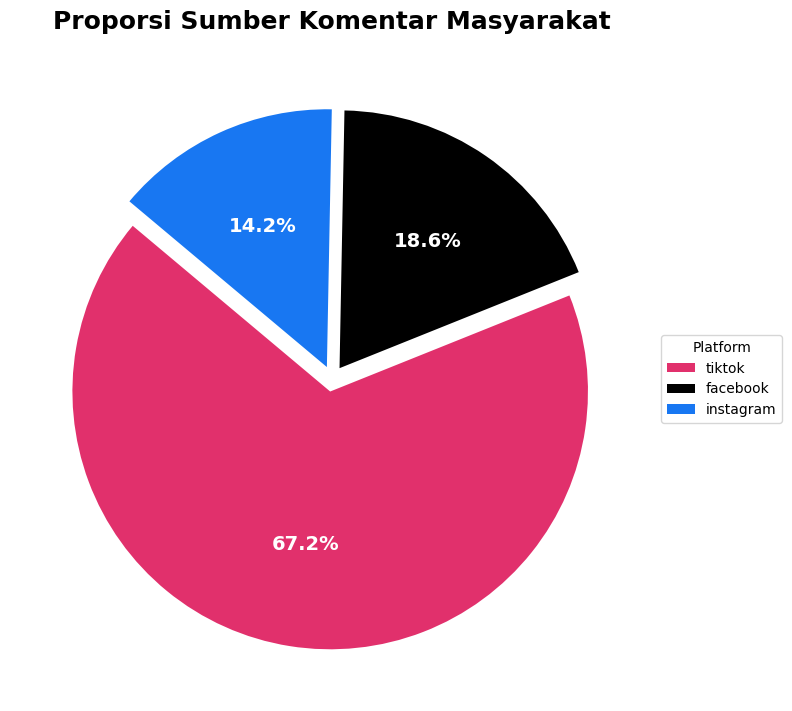


✅ Tabel dan visualisasi platform berhasil dibuat. Gambar disimpan di 'image_thr/pie_chart_platform_thr.png'!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset platform.xlsx (Sesuaikan path folder 'data/' jika diperlukan)
print("Membaca data platform.xlsx...")
df_platform = pd.read_excel('data/dataset_thr.xlsx') # Ubah menjadi 'platform.xlsx' jika tidak di dalam folder data

# 2. Menghitung total dan persentase dari kolom 'platform'
# value_counts() menghitung total, normalize=True merubahnya jadi proporsi (0.0 - 1.0)
total_platform = df_platform['platform'].value_counts()
persen_platform = df_platform['platform'].value_counts(normalize=True) * 100

# 3. Menggabungkan hasilnya ke dalam satu tabel DataFrame agar rapi
df_ringkasan_platform = pd.DataFrame({
    'Jumlah Komentar': total_platform,
    'Persentase (%)': persen_platform.round(2) # round(2) membatasi 2 angka di belakang koma
})

# Menambahkan nama untuk kolom index
df_ringkasan_platform.index.name = 'Platform Sosial Media'

print("\n--- TABEL PERSENTASE PLATFORM ---")
display(df_ringkasan_platform)

# 4. Membuat Visualisasi Pie Chart (Opsional, tapi sangat bagus untuk laporan)
plt.figure(figsize=(8, 8))

# Menentukan warna khusus untuk tiap platform agar representatif
warna_platform = ['#E1306C', '#000000', '#1877F2'] # Warna khas IG (Pink), TikTok (Hitam), FB (Biru)

plt.pie(
    persen_platform, 
    labels=persen_platform.index, 
    autopct='%1.1f%%', # Menampilkan angka persentase di dalam pie
    startangle=140, 
    colors=warna_platform,
    explode=[0.05] * len(persen_platform), # Memberikan jarak/potongan antar pie agar estetik
    textprops={'fontsize': 14, 'fontweight': 'bold', 'color': 'white'} # Warna teks di dalam pie
)

# Menambahkan legend (keterangan) di luar pie chart
plt.legend(persen_platform.index, title="Platform", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.title('Proporsi Sumber Komentar Masyarakat', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()

# Simpan grafik
path_pie = "image_thr/pie_chart_platform_thr.png"
plt.savefig(path_pie, bbox_inches='tight', dpi=150)
plt.show()

print(f"\n✅ Tabel dan visualisasi platform berhasil dibuat. Gambar disimpan di '{path_pie}'!")

Label unik: ['negative' 'neutral' 'positive']


C:\Users\Toshiba Racing\AppData\Local\Temp\ipykernel_12092\2685994346.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


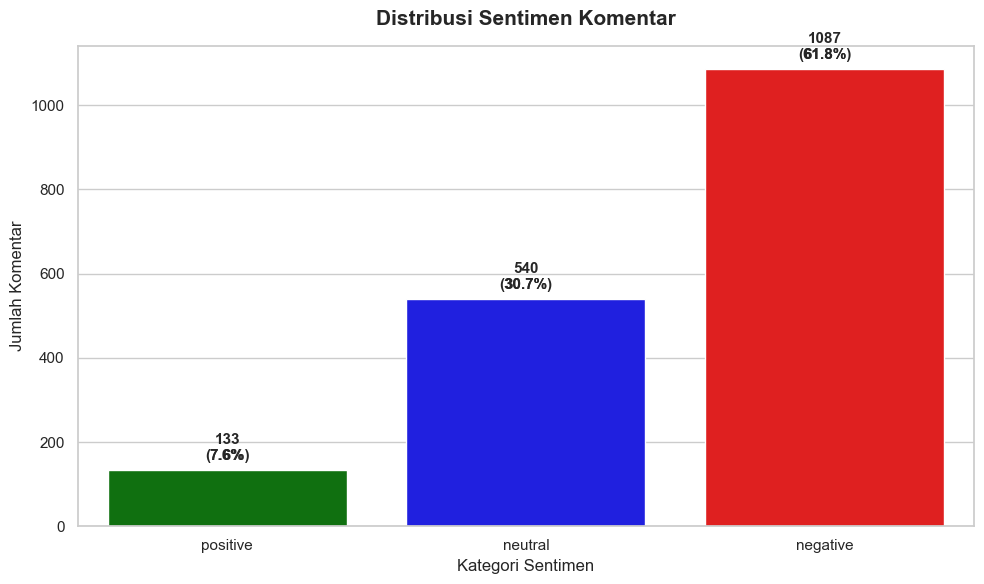

Analisis selesai menggunakan 1760 data.


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ========================================================
# 1. Load Data
# ========================================================
df = pd.read_excel('data/df_labeled_thr.xlsx')

# Gunakan kolom sentiment (karena ini yang valid)
print("Label unik:", df['sentiment'].unique())

# ========================================================
# 2. Setting Visual
# ========================================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

palette_colors = {
    'positive': 'green',
    'neutral': 'blue',
    'negative': 'red'
}

# ========================================================
# 3. Distribusi Sentimen
# ========================================================
ax = sns.countplot(
    data=df,
    x='sentiment',
    order=['positive', 'neutral', 'negative'],
    palette=palette_colors
)

plt.title('Distribusi Sentimen Komentar', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Kategori Sentimen', fontsize=12)
plt.ylabel('Jumlah Komentar', fontsize=12)

# ========================================================
# 4. Tambahkan Label (Jumlah + Persentase)
# ========================================================
total = len(df)

for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100

    ax.annotate(
        f'{int(height)}\n({percentage:.1f}%)',
        (p.get_x() + p.get_width() / 2, height),
        ha='center', va='bottom',
        fontsize=11, fontweight='bold',
        xytext=(0, 5), textcoords='offset points'
    )

for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100

    ax.annotate(
        f'{percentage:.1f}%',
        (p.get_x() + p.get_width() / 2, height),
        ha='center', va='bottom',
        fontsize=11, fontweight='bold',
        xytext=(0, 5), textcoords='offset points'
    )

# ========================================================
# 5. Simpan & Tampilkan
# ========================================================
plt.tight_layout()

# Pastikan folder ada
# os.makedirs("image_thr", exist_ok=True)

plt.savefig("image_thr/distribusi_sentimen.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Analisis selesai menggunakan {total} data.")

In [4]:
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

from wordcloud import STOPWORDS

# 1. Definisikan stopwords dasar dan tambahan Anda
custom_stopwords = set(STOPWORDS)
custom_stopwords.update({
    'tos', 'bp', 'pa', 'nu', 'ge', 'anu', 'bu', 'pis', 'kakak', 'teu', 
    'ah', 'bade', 'bup', 'abi', 'kang', 'mis', 'si', 'krna', 
    'les', 'ala', 'box', 'rb', 'pas', 'ti', 'sd'
})

# 2. Baru jalankan bagian CountVectorizer
# vec = CountVectorizer(ngram_range=(2, 3), stop_words=list(custom_stopwords))

# **WC Positive**

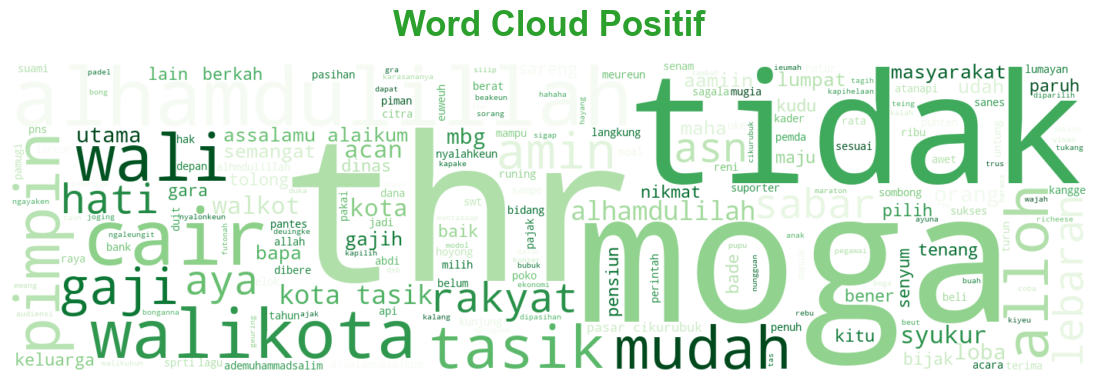

In [8]:
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import os

# Load data
df = pd.read_excel('data/df_labeled_thr.xlsx')

# Stopwords dasar
base_stopwords = set(STOPWORDS)
base_stopwords.update({
    'bp','pa','nu','ge','anu','bu','teu','mah','weh',
    'abi','kang','si','krna','ah','gak','gk', "adil",
    "nya", "sdh", "bd", "hak2", "yaa", "kes", "sbg",
    "loh", "sama2", "meuni", "na", "sebaik2", "pas",
    'bp','pa','nu','ge','anu','bu','teu','mah','weh',
    'abi','kang','si','krna','ah','gak','gk',  "teu",
    'mantap', 'bagus', 'sehat', "atuh", "geus", "teu",
    "kan", "jeung", "ttp", "pas", "oge", "te", "tuh", "yaa",
    "d", "sih", "bet", "yang", "lho", "ek", "n", "jas", "ttp",
    "boa", "kn", "d", "di", "keur", "ka", "ning", "pis", "ari",
    "da", "wae", "usah", "jd", "asa", "ges", "mh", "mah", "ttp",
    "dong", "g", "te", "di", "tah", "ges", "bet", "jd", "kan",
    "et", "ges", "geus", "ek", 'mantap', 'bagus', 'sehat', "atuh",
    "kan", "jeung", "ttp", "pas", "oge", "te", "tuh", "yaa",
    "d", "sih", "bet", "yang", "lho", "ek", "n", "jas", "ttp",
    "boa", "kn", "d", "di", "keur", "ka", "ning", "pis", "ari",
    "da", "wae", "usah", "jd", "asa", "ges", "mh", "mah", "ttp",
    "dong", "g", "geus", "p"
})

# 🚩 EDIT KHUSUS POSITIVE DI SINI
stop_positive = base_stopwords.copy()
stop_positive.update([
    'jalan', 'kerja', 'bagus', "pak", "ada", "atuh",
    "sakira", 'mantap', 'bagus', 'sehat', "atuh", "geus", "teu",
    "kan", "jeung", "ttp", "pas", "oge", "te", "tuh", "yaa",
    "d", "sih", "bet", "yang", "lho", "ek", "n", "jas", "ttp",
    "boa", "kn", "d", "di", "keur", "ka", "ning", "pis", "ari",
    "da", "wae", "usah", "jd", "asa", "ges", "mh", "mah", "ttp",
    "dong", "g", "te", "di", "tah", "ges", "bet", "jd", "kan",
    "et", "ges", "geus", "ek", 'mantap', 'bagus', 'sehat', "atuh",
    "kan", "jeung", "ttp", "pas", "oge", "te", "tuh", "yaa",
    "d", "sih", "bet", "yang", "lho", "ek", "n", "jas", "ttp",
    "boa", "kn", "d", "di", "keur", "ka", "ning", "pis", "ari",
    "da", "wae", "usah", "jd", "asa", "ges", "mh", "mah", "ttp",
    "dong", "g", "geus", "teu", "ku", "tp", "ath", "ti", "aja", "1",
    "2", "l", "i"," I", "bpk", "cuma", "ieu", "ke", "samaaaa", "paling",
    "pada", "k10", "meni", "euy", "jga", "jln", "ga", "biar", "pk",
    "rb", "dn", "dll", "tong", "keneh", "jg", "pisan", "cik", "lah",
    "t", "tos", "tdk", "gening", "se", "deui", "klo", "mun", "ya", "itu",
    "sll", "sblm", "jl", "jang", "dah", "boro", "sm", "gas"
])

# Ambil teks positive
teks = " ".join(df[df['sentiment'] == 'positive']['text_akhir'].astype(str))

wc = WordCloud(
    width=1400,
    height=400,
    background_color='white',
    colormap='Greens',
    stopwords=stop_positive,
).generate(teks)

plt.figure(figsize=(16,4))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')

plt.title("Word Cloud Positif", fontsize=25, fontweight='bold', color='#2ca02c', pad=20)

plt.savefig(
    "image_thr/wc_positive.png",
    dpi=300,
    bbox_inches='tight',
    pad_inches=0.5
)

plt.show()

# **WC Negative**

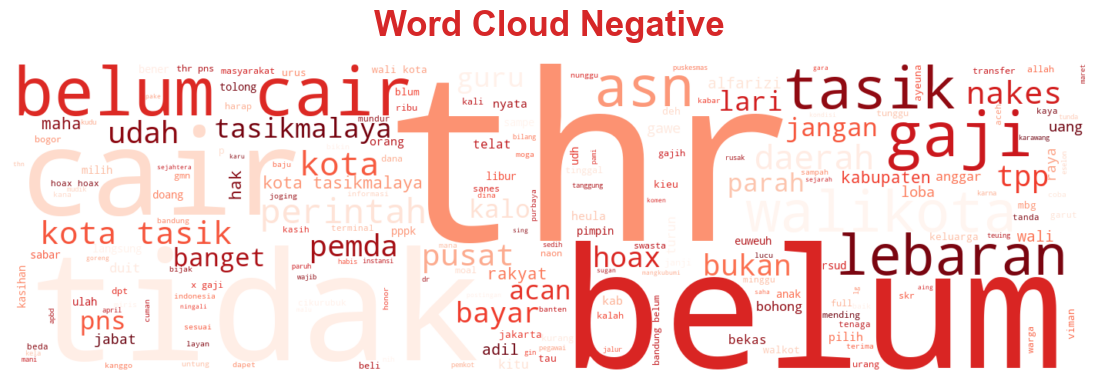

In [12]:
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import os

# Load data
df = pd.read_excel('data/df_labeled_thr.xlsx')

# Stopwords dasar
base_stopwords = set(STOPWORDS)
base_stopwords.update({
    'bp','pa','nu','ge','anu','bu','teu','mah','weh',
    'abi','kang','si','krna','ah','gak','gk',
    'mantap', 'bagus', 'sehat', "atuh", "geus", "teu",
    "kan", "jeung", "ttp", "pas", "oge", "te", "tuh", "yaa",
    "d", "sih", "bet", "yang", "lho", "ek", "n", "jas", "ttp",
    "boa", "kn", "d", "di", "keur", "ka", "ning", "pis", "ari",
    "da", "wae", "usah", "jd", "asa", "ges", "mh", "mah", "ttp",
    "dong", "g", "te", "di", "tah", "ges", "bet", "jd", "kan",
    "et", "ges", "geus", "ek", 'mantap', 'bagus', 'sehat', "atuh",
    "kan", "jeung", "ttp", "pas", "oge", "te", "tuh", "yaa",
    "d", "sih", "bet", "yang", "lho", "ek", "n", "jas", "ttp",
    "boa", "kn", "d", "di", "keur", "ka", "ning", "pis", "ari",
    "da", "wae", "usah", "jd", "asa", "ges", "mh", "mah", "ttp",
    "dong", "g", "geus", "teu",
})

# 🚩 EDIT KHUSUS NEGATIVE
stop_negative = base_stopwords.copy()
stop_negative.update([
    'mantap', 'bagus', 'sehat', "atuh", "geus", "teu",
    "kan", "jeung", "ttp", "pas", "oge", "te", "tuh", "yaa",
    "d", "sih", "bet", "yang", "lho", "ek", "n", "jas", "ttp",
    "boa", "kn", "d", "di", "keur", "ka", "ning", "pis", "ari",
    "da", "wae", "usah", "jd", "asa", "ges", "mh", "mah", "ttp",
    "dong", "g", "te", "di", "tah", "ges", "bet", "jd", "kan",
    "et", "ges", "geus", "ek", 'mantap', 'bagus', 'sehat', "atuh",
    "kan", "jeung", "ttp", "pas", "oge", "te", "tuh", "yaa",
    "d", "sih", "bet", "yang", "lho", "ek", "n", "jas", "ttp",
    "boa", "kn", "d", "di", "keur", "ka", "ning", "pis", "ari",
    "da", "wae", "usah", "jd", "asa", "ges", "mh", "mah", "ttp",
    "dong", "g", "geus", "teu", "na", "aya", "ada", 'jalan', 'kerja', 
    "sakira", 'mantap', 'bagus', 'sehat', "atuh", "geus", "teu",
    "kan", "jeung", "ttp", "pas", "oge", "te", "tuh", "yaa",
    "d", "sih", "bet", "yang", "lho", "ek", "n", "jas", "ttp",
    "boa", "kn", "d", "di", "keur", "ka", "ning", "pis", "ari",
    "da", "wae", "usah", "jd", "asa", "ges", "mh", "mah", "ttp",
    "dong", "g", "te", "di", "tah", "ges", "bet", "jd", "kan",
    "et", "ges", "geus", "ek", 'mantap', 'bagus', 'sehat', "atuh",
    "kan", "jeung", "ttp", "pas", "oge", "te", "tuh", "yaa",
    "d", "sih", "bet", "yang", "lho", "ek", "n", "jas", "ttp",
    "boa", "kn", "d", "di", "keur", "ka", "ning", "pis", "ari",
    "da", "wae", "usah", "jd", "asa", "ges", "mh", "mah", "ttp",
    "dong", "g", "geus", "teu", "ku", "tp", "ath", "ti", "aja", "1",
    "2", "l", "i"," I", "bpk", "cuma", "ieu", "ke", "samaaaa", "paling",
    "pada", "k10", "meni", "euy", "jga", "jln", "ga", "biar", "pk",
    "rb", "dn", "dll", "tong", "keneh", "jg", "pisan", "cik", "lah",
    "t", "tos", "tdk", "gening", "se", "deui", "klo", "mun", "ya", "itu",
    "sll", "sblm", "jl", "jang", "dah", "boro", "emang", "bom", "pp",
    'bagus', "pak", "ada", "atuh", "pw", "h", "sdh", "ko", "th"
])

# Ambil teks positive
teks = " ".join(df[df['sentiment'] == 'negative']['text_akhir'].astype(str))

wc = WordCloud(
    width=1400,
    height=400,
    background_color='white',
    colormap='Reds',
    stopwords=stop_negative,
).generate(teks)

plt.figure(figsize=(16,4))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')

plt.title("Word Cloud Negative", fontsize=25, fontweight='bold', color='#d62728', pad=20)

plt.savefig(
    "image_thr/wc_negative.png",
    dpi=300,
    bbox_inches='tight',
    pad_inches=0.5
)

plt.show()

# **WC Neutral**

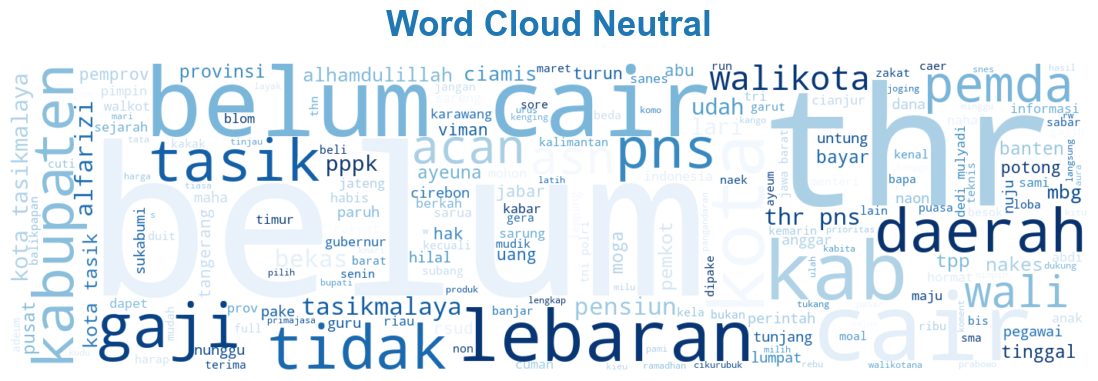

In [7]:
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import os

# Load data
df = pd.read_excel('data/df_labeled_thr.xlsx')

base_stopwords = set(STOPWORDS)
base_stopwords.update({
    'bp','pa','nu','ge','anu','bu','teu','mah','weh',
    'abi','kang','si','krna','ah','gak','gk', 'bp','pa',
    'nu','ge','anu','bu','teu','mah','weh', "pas"
    'abi','kang','si','krna','ah','gak','gk', "adil",
    "nya", "sdh", "bd", "hak2", "yaa", "kes", "sbg",
    "loh", "sama2", "meuni", "na", "sebaik2", "pas",
    'bp','pa','nu','ge','anu','bu','teu','mah','weh',
    'abi','kang','si','krna','ah','gak','gk', "adil",
    "nya", "sdh", "bd", "hak2", "yaa", "kes", "sbg",
    "loh", "sama2", "meuni", "na", "sebaik2", "tos",
    "ter", "klu"
})

# 🚩 EDIT KHUSUS NEUTRAL
stop_neutral = base_stopwords.copy()
stop_neutral.update([
    'mantap', 'bagus', 'sehat', "atuh", "geus", "teu",
    "kan", "jeung", "ttp", "pas", "oge", "te", "tuh", "yaa",
    "d", "sih", "bet", "yang", "lho", "ek", "n", "jas", "ttp",
    "boa", "kn", "d", "di", "keur", "ka", "ning", "pis", "ari",
    "da", "wae", "usah", "jd", "asa", "ges", "mh", "mah", "ttp",
    "dong", "g", "ti", "th", "h7", "teh", "gin", "dr", "pan", "nah",
    "tah", "eta", "tjuy", "sempet2nya", "itu", "deui", "tag",
    "lah", "bro", "se", "heula", 'bagus', "pak", "ada", "atuh",
    'mantap', 'bagus', 'sehat', "atuh", "geus", "teu",
    "kan", "jeung", "ttp", "pas", "oge", "te", "tuh", "yaa",
    "d", "sih", "bet", "yang", "lho", "ek", "n", "jas", "ttp",
    "boa", "kn", "d", "di", "keur", "ka", "ning", "pis", "ari",
    "da", "wae", "usah", "jd", "asa", "ges", "mh", "mah", "ttp",
    "dong", "g", "te", "di", "tah", "ges", "bet", "jd", "kan",
    "et", "ges", "geus", "ek", 'mantap', 'bagus', 'sehat', "atuh",
    "kan", "jeung", "ttp", "pas", "oge", "te", "tuh", "yaa",
    "d", "sih", "bet", "yang", "lho", "ek", "n", "jas", "ttp",
    "boa", "kn", "d", "di", "keur", "ka", "ning", "pis", "ari",
    "da", "wae", "usah", "jd", "asa", "ges", "mh", "mah", "ttp",
    "dong", "g", "geus", "teu", "na", "aya", "ada", 'jalan', 'kerja',
    "sakira", 'mantap', 'bagus', 'sehat', "atuh", "geus", "teu",
    "kan", "jeung", "ttp", "pas", "oge", "te", "tuh", "yaa",
    "d", "sih", "bet", "yang", "lho", "ek", "n", "jas", "ttp",
    "boa", "kn", "d", "di", "keur", "ka", "ning", "pis", "ari",
    "da", "wae", "usah", "jd", "asa", "ges", "mh", "mah", "ttp",
    "dong", "g", "te", "di", "tah", "ges", "bet", "jd", "kan",
    "et", "ges", "geus", "ek", 'mantap', 'bagus', 'sehat', "atuh",
    "kan", "jeung", "ttp", "pas", "oge", "te", "tuh", "yaa",
    "d", "sih", "bet", "yang", "lho", "ek", "n", "jas", "ttp",
    "boa", "kn", "d", "di", "keur", "ka", "ning", "pis", "ari",
    "da", "wae", "usah", "jd", "asa", "ges", "mh", "mah", "ttp",
    "dong", "g", "geus", "teu", "ku", "tp", "ath", "ti", "aja", "1",
    "2", "l", "i"," I", "bpk", "cuma", "ieu", "ke", "samaaaa", "paling",
    "pada", "k10", "meni", "euy", "jga", "jln", "ga", "biar", "pk",
    "rb", "dn", "dll", "tong", "keneh", "jg", "pisan", "cik", "lah",
    "t", "tos", "tdk", "gening", "se", "deui", "klo", "mun", "ya", "itu",
    "sll", "sblm", "jl", "jang", "dah", "boro", "sm", "nih", "tgl",
    "sing", "h", "ri", "pp", "skr", "pw", "smg", "kmha", "x", "X", "p", "P",
    "kak", "aceh", "jakarta", "bom", "bandung", "bogor", "ih", "oh", "udh"
])

# Ambil teks positive
teks = " ".join(df[df['sentiment'] == 'neutral']['text_akhir'].astype(str))

wc = WordCloud(
    width=1400,
    height=400,
    background_color='white',
    colormap='Blues',
    stopwords=stop_neutral,
).generate(teks)

plt.figure(figsize=(16,4))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')

plt.title("Word Cloud Neutral", fontsize=25, fontweight='bold', color='#1f77b4', pad=20)

plt.savefig(
    "image_thr/wc_neutral.png",
    dpi=300,
    bbox_inches='tight',
    pad_inches=0.5
)

plt.show()

C:\Users\Toshiba Racing\AppData\Local\Temp\ipykernel_12092\3411602398.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_kata = df_fix['text_akhir'].str.contains(pola_kata, case=False, na=False, regex=True)


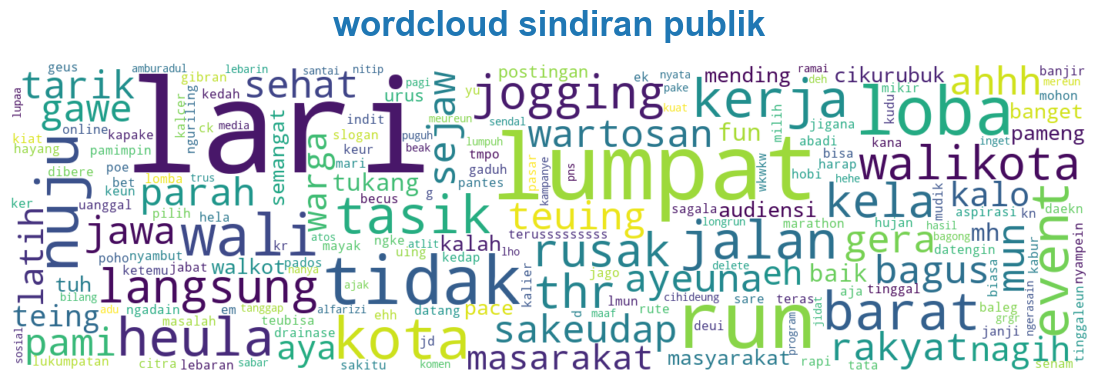

In [21]:
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# 1. Load data
df_fix = pd.read_excel('data/df_labeled_thr.xlsx')

# 2. Kata-kata manual untuk sindiran “lari/run”
kata_manual = ["lari", "run", "pace", "lumpat", "marathon", "jogging", "event"]

# 3. Regex pintar untuk semua kata sekaligus
pola_kata = r'\b(' + '|'.join(kata_manual) + r')\b'

# 4. Filter dataframe agar hanya berisi kata manual
mask_kata = df_fix['text_akhir'].str.contains(pola_kata, case=False, na=False, regex=True)
df_result = df_fix[mask_kata]

# 5. Gabungkan semua teks untuk wordcloud
teks = " ".join(df_result['text_akhir'].astype(str))

# 6. Stopwords (pakai stopwords versi neutral)
base_stopwords = set(STOPWORDS)
base_stopwords.update({
    'bp','pa','nu','ge','anu','bu','teu','mah','weh',
    'abi','kang','si','krna','ah','gak','gk', "pas",
    "adil", "nya", "sdh", "bd", "hak2", "yaa", "kes", "sbg",
    "loh", "sama2", "meuni", "na", "sebaik2", "tos",
    "ter", "klu"
})
stopwords_final = base_stopwords

# 7. WordCloud
wc = WordCloud(
    width=1400,
    height=400,
    background_color='white',
    colormap='viridis',
    stopwords=stopwords_final,
    min_font_size=10
).generate(teks)

# 8. Tampilkan wordcloud
plt.figure(figsize=(16,4))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("wordcloud sindiran publik", fontsize=25, fontweight='bold', color='#1f77b4', pad=20)

# 9. Simpan
plt.savefig(
    "image_thr/wc_sindiran_lari.png",
    dpi=300,
    bbox_inches='tight',
    pad_inches=0.5
)

plt.show()

In [27]:
import pandas as pd
import re

# 1. Load dataset
df_fix = pd.read_excel('data/df_labeled_thr.xlsx')
df_fix = df_fix.dropna(subset=['text_akhir'])

# 2. Total data
total_data = len(df_fix)

# 3. INPUT KATA MANUAL DI SINI
target_kata = ["lari", "run", "pelari", "kalcer", "jogging", "lumpat", "marathon", "event"]

# 4. Gabungkan semua teks
text_all = " ".join(df_fix['text_akhir'].astype(str))

# 5. Tokenisasi
words = re.findall(r'\b\w+\b', text_all.lower())

# 6. Hitung frekuensi per kata manual
hasil = {}

for kata in target_kata:
    jumlah = words.count(kata.lower())
    persen = (jumlah / total_data) * 100
    hasil[kata] = (jumlah, persen)

# 7. Tampilkan hasil
print("HASIL ANALISIS KATA (MANUAL)\n")

for kata, (jumlah, persen) in hasil.items():
    print(f"{kata:10} | Jumlah: {jumlah:4} | Persen: {persen:.2f}%")

HASIL ANALISIS KATA (MANUAL)

lari       | Jumlah:   34 | Persen: 1.93%
run        | Jumlah:   10 | Persen: 0.57%
pelari     | Jumlah:    0 | Persen: 0.00%
kalcer     | Jumlah:    1 | Persen: 0.06%
jogging    | Jumlah:    3 | Persen: 0.17%
lumpat     | Jumlah:   14 | Persen: 0.80%
marathon   | Jumlah:    1 | Persen: 0.06%
event      | Jumlah:    4 | Persen: 0.23%


In [40]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# 1. Load data murni
df_fix = pd.read_excel('data_wakil/df_labeled_fix_wakil.xlsx')
df_fix = df_fix.dropna(subset=['text_akhir'])

# 2. Dapatkan daftar wilayah unik
list_wilayah = df_fix['government'].unique()

print("="*75)
print("   ANALISIS DOMINASI TOPIK: TOP 10 FRASA (DALAM PERSENTASE)")
print("="*75)

# 3. Looping untuk setiap wilayah
for wilayah in list_wilayah:
    # Filter data berdasarkan wilayah
    df_wilayah = df_fix[df_fix['government'] == wilayah]
    teks_wilayah = df_wilayah['text_akhir'].astype(str)
    
    # Hitung total baris data di wilayah ini untuk pembagi persen
    total_data_wilayah = len(df_wilayah)
    
    print(f"\n📍 WILAYAH: {wilayah} (Total Data: {total_data_wilayah})")
    
    if not teks_wilayah.empty:
        # Menggunakan N-Gram sesuai preferensi Anda sebelumnya (>5 kata)
        # Atau silakan ubah kembali ke (2, 3) jika ingin frasa lebih pendek
        vec = CountVectorizer(ngram_range=(2, 3), stop_words=list(custom_stopwords))
        
        try:
            X = vec.fit_transform(teks_wilayah)
            
            # Hitung frekuensi absolut
            sum_words = X.sum(axis=0)
            words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
            words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
            
            # Ambil Top 10
            top_10 = words_freq[:5]
            
            if top_10:
                for i, (topic, freq) in enumerate(top_10, 1):
                    # Hitung Persentase Dominasi
                    persen = (freq / total_data_wilayah) * 100
                    print(f"   {i}. {topic.lower()}")
                    print(f"      {persen:.1f}% ({freq} kali muncul)")
            else:
                print("   (Tidak ditemukan pola topik yang signifikan)")
                
        except ValueError:
            print("   (Data teks terlalu minim untuk analisis)")
    else:
        print("   (Data tidak tersedia)")

print("\n" + "="*75)

   ANALISIS DOMINASI TOPIK: TOP 10 FRASA (DALAM PERSENTASE)

📍 WILAYAH: Kota Tasikmalaya (Total Data: 479)
   1. menu mbg
      2.1% (10 kali muncul)
   2. mbg bagus
      1.7% (8 kali muncul)
   3. moga langgeng
      1.7% (8 kali muncul)
   4. jahat kelamin
      1.3% (6 kali muncul)
   5. sehat sllu
      1.3% (6 kali muncul)

📍 WILAYAH: Kota Banjar (Total Data: 39)
   1. kartu daya
      5.1% (2 kali muncul)
   2. protes langsung
      5.1% (2 kali muncul)
   3. alhamdullillah maju
      2.6% (1 kali muncul)
   4. maju bangun
      2.6% (1 kali muncul)
   5. bangun jalan
      2.6% (1 kali muncul)

📍 WILAYAH: Kabupaten Garut (Total Data: 529)
   1. perempuan putri
      2.3% (12 kali muncul)
   2. bikin ktp
      1.5% (8 kali muncul)
   3. hatur nuhun
      1.3% (7 kali muncul)
   4. wakil bupati
      1.3% (7 kali muncul)
   5. orang tua
      1.3% (7 kali muncul)

📍 WILAYAH: Kabupaten Pangandaran (Total Data: 71)
   1. jadi bupati
      4.2% (3 kali muncul)
   2. barelegug kabeh


C:\Users\Toshiba Racing\env11\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(
C:\Users\Toshiba Racing\env11\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(
C:\Users\Toshiba Racing\env11\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words genera


📍 WILAYAH: Kabupaten Ciamis (Total Data: 39)
   1. wani piro
      7.7% (3 kali muncul)
   2. wakil bupati
      7.7% (3 kali muncul)
   3. ga ada
      7.7% (3 kali muncul)
   4. gak usah
      5.1% (2 kali muncul)
   5. aya wakil
      5.1% (2 kali muncul)



In [41]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# 1. Load data yang sudah 2 sentimen
df = pd.read_excel('data_wakil/df_labeled_fix_wakil.xlsx')
df = df.dropna(subset=['text_akhir'])

# 2. Dapatkan daftar wilayah unik
list_wilayah = df['government'].unique()

print("="*60)
print("   ANALISIS TOPIK: TOP 3 ISU UTAMA PER WILAYAH")
print("="*60)

# 3. Looping untuk setiap wilayah
for wilayah in list_wilayah:
    # Filter data berdasarkan wilayah
    df_wilayah = df[df['government'] == wilayah]
    teks_wilayah = df_wilayah['text_akhir'].astype(str)
    
    print(f"\n📍 WILAYAH: {wilayah}")
    
    if not teks_wilayah.empty:
        # Menggunakan Bigram (2 kata) & Trigram (3 kata) untuk konteks yang lebih jelas
        # Stopwords menggunakan set yang sudah kita definisikan sebelumnya
        vec = CountVectorizer(ngram_range=(2, 3), stop_words=list(custom_stopwords))
        
        try:
            X = vec.fit_transform(teks_wilayah)
            
            # Hitung frekuensi
            sum_words = X.sum(axis=0)
            words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
            words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
            
            # Ambil Top 3
            top_3 = words_freq[:10]
            
            if top_3:
                for i, (topic, freq) in enumerate(top_3, 1):
                    print(f"   {i}. {topic.upper()} ({freq} kali)")
            else:
                print("   (Tidak ditemukan pola topik yang signifikan)")
                
        except ValueError:
            # Menangani jika teks terlalu pendek untuk dibuat ngram
            print("   (Data teks terlalu minim untuk analisis topik)")
    else:
        print("   (Data tidak tersedia)")

print("\n" + "="*60)

   ANALISIS TOPIK: TOP 3 ISU UTAMA PER WILAYAH

📍 WILAYAH: Kota Tasikmalaya
   1. MENU MBG (10 kali)
   2. MBG BAGUS (8 kali)
   3. MOGA LANGGENG (8 kali)
   4. JAHAT KELAMIN (6 kali)
   5. SEHAT SLLU (6 kali)
   6. MOGA SEHAT (6 kali)
   7. WATIR IH (6 kali)
   8. PEREMPUAN RANI (6 kali)
   9. ROTI TAWAR (4 kali)
   10. MOGA BAHAGIA (4 kali)

📍 WILAYAH: Kota Banjar
   1. KARTU DAYA (2 kali)
   2. PROTES LANGSUNG (2 kali)
   3. ALHAMDULLILLAH MAJU (1 kali)
   4. MAJU BANGUN (1 kali)
   5. BANGUN JALAN (1 kali)
   6. JALAN SAE (1 kali)
   7. SAE RUTILAHU (1 kali)
   8. RUTILAHU LAKSANA (1 kali)
   9. LAKSANA WUJUD (1 kali)
   10. WUJUD PROGRAM (1 kali)

📍 WILAYAH: Kabupaten Garut
   1. PEREMPUAN PUTRI (12 kali)
   2. BIKIN KTP (8 kali)
   3. HATUR NUHUN (7 kali)
   4. WAKIL BUPATI (7 kali)
   5. ORANG TUA (7 kali)
   6. NAEK KANU (6 kali)
   7. TERIMA KASIH (6 kali)
   8. GARUT HEBAT (5 kali)
   9. MOGA ALLAH (5 kali)
   10. ALLAH SWT (5 kali)

📍 WILAYAH: Kabupaten Pangandaran
   1. JAD

C:\Users\Toshiba Racing\env11\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(
C:\Users\Toshiba Racing\env11\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(
C:\Users\Toshiba Racing\env11\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words genera

   1. JAHAT KELAMIN (8 kali)
   2. ASLI PALSU (8 kali)
   3. HATUR NUHUN (6 kali)
   4. KABUPATEN TASIKMALAYA (4 kali)
   5. JALAN DESA (4 kali)
   6. BAIK JALAN (4 kali)
   7. SALUR AIR (4 kali)
   8. JALAN MULUS (4 kali)
   9. JALAN AWON (4 kali)
   10. MANTAP WABUP (3 kali)

📍 WILAYAH: Kabupaten Ciamis
   1. WANI PIRO (3 kali)
   2. WAKIL BUPATI (3 kali)
   3. GA ADA (3 kali)
   4. GAK USAH (2 kali)
   5. AYA WAKIL (2 kali)
   6. LILA PISAN (2 kali)
   7. TINGAL TUNJUK (1 kali)
   8. TUNJUK ORANGNYA (1 kali)
   9. ORANGNYA TAPI (1 kali)
   10. TAPI WAKILNYA (1 kali)



C:\Users\Toshiba Racing\env11\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(


# **TOP 3 Positif Negatif Per Wilayah**

In [42]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# 1. Load data
df = pd.read_excel('data_wakil/df_labeled_fix_wakil.xlsx')
df = df.dropna(subset=['text_akhir'])

# 2. Ambil daftar wilayah unik
list_wilayah = df['government'].unique()

print("="*70)
print("   ANALISIS MENDALAM: TOP 3 KRITIK VS TOP 3 APRESIASI PER WILAYAH")
print("="*70)

# 3. Looping per wilayah
for wilayah in list_wilayah:
    print(f"\n📍 WILAYAH: {wilayah}")
    
    # Filter data wilayah
    df_wilayah = df[df['government'] == wilayah]
    
    # --- PROSES TIAP SENTIMEN ---
    for sentimen in ['negative', 'positive']:
        label_header = "KRITIK UTAMA (NEGATIF)" if sentimen == 'negative' else "APRESIASI/SARAN (POSITIF)"
        
        # Filter teks berdasarkan sentimen
        teks_sentimen = df_wilayah[df_wilayah['sentiment_label'] == sentimen]['text_akhir'].astype(str)
        
        print(f"   ➤ {label_header}:")
        
        if not teks_sentimen.empty:
            # Ekstraksi N-Gram (2-3 kata) agar lebih bermakna
            vec = CountVectorizer(ngram_range=(2, 3), stop_words=list(custom_stopwords))
            
            try:
                X = vec.fit_transform(teks_sentimen)
                sum_words = X.sum(axis=0)
                words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
                words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
                
                # Ambil Top 3
                top_3 = words_freq[:40]
                
                if top_3:
                    for i, (topic, freq) in enumerate(top_3, 1):
                        print(f"      {i}. {topic.upper()} ({freq} kali)")
                else:
                    print("      (Topik tidak cukup dominan untuk dikelompokkan)")
            except:
                print("      (Data teks terlalu minim untuk analisis)")
        else:
            print("      (Tidak ditemukan data untuk kategori ini)")
    print("-" * 50)

print("\n" + "="*70)

   ANALISIS MENDALAM: TOP 3 KRITIK VS TOP 3 APRESIASI PER WILAYAH

📍 WILAYAH: Kota Tasikmalaya
   ➤ KRITIK UTAMA (NEGATIF):
      1. JAHAT KELAMIN (6 kali)
      2. WATIR IH (6 kali)
      3. JANGAN KUNJUNG (4 kali)
      4. ARI TETEH (4 kali)
      5. PEREMPUAN RANI (4 kali)
      6. RANI MANI (4 kali)
      7. PEREMPUAN RANI MANI (4 kali)
      8. KELAMIN WAKIL (4 kali)
      9. WAKIL WALKOT (4 kali)
      10. JAHAT KELAMIN WAKIL (4 kali)
      11. KELAMIN WAKIL WALKOT (4 kali)
      12. KEREN ANAK (2 kali)
      13. ANAK BUAK (2 kali)
      14. BUAK ATIK (2 kali)
      15. KEREN ANAK BUAK (2 kali)
      16. ANAK BUAK ATIK (2 kali)
      17. TEMPAT MBG (2 kali)
      18. MBG PARAH (2 kali)
      19. TEMPAT MBG PARAH (2 kali)
      20. TUNGAK JENGUK (2 kali)
      21. JENGUK DOANG (2 kali)
      22. DOANG MAMAT (2 kali)
      23. MAMAT KERJA (2 kali)
      24. KERJA KITU (2 kali)
      25. TUNGAK JENGUK DOANG (2 kali)
      26. JENGUK DOANG MAMAT (2 kali)
      27. DOANG MAMAT KERJA (

C:\Users\Toshiba Racing\env11\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(
C:\Users\Toshiba Racing\env11\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(
C:\Users\Toshiba Racing\env11\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words genera

      1. JADI BUPATI (3 kali)
      2. BARELEGUG KABEH (2 kali)
      3. KABEH DIBERITAKEUN (2 kali)
      4. SAACAN CITRA (2 kali)
      5. CITRA JEUNG (2 kali)
      6. JEUNG INO (2 kali)
      7. BUPATI JEUNG (2 kali)
      8. JEUNG WAKIL (2 kali)
      9. WAKIL BUPATI (2 kali)
      10. BARELEGUG KABEH DIBERITAKEUN (2 kali)
      11. SAACAN CITRA JEUNG (2 kali)
      12. CITRA JEUNG INO (2 kali)
      13. BUPATI JEUNG WAKIL (2 kali)
      14. JEUNG WAKIL BUPATI (2 kali)
      15. GIN WAJAR (2 kali)
      16. BALIK MODAL (2 kali)
      17. MAAF LONJAK (1 kali)
      18. LONJAK FANTASTIS (1 kali)
      19. FANTASTIS TURUN (1 kali)
      20. TURUN DRASTIS (1 kali)
      21. MAAF LONJAK FANTASTIS (1 kali)
      22. LONJAK FANTASTIS TURUN (1 kali)
      23. FANTASTIS TURUN DRASTIS (1 kali)
      24. PANTES JALAN (1 kali)
      25. JALAN LEMBUR (1 kali)
      26. LEMBUR RARUJAD (1 kali)
      27. PANTES JALAN LEMBUR (1 kali)
      28. JALAN LEMBUR RARUJAD (1 kali)
      29. BANGUN TURUN 

C:\Users\Toshiba Racing\env11\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(
C:\Users\Toshiba Racing\env11\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(
C:\Users\Toshiba Racing\env11\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words genera

# **Keyword Based-Extraction**

In [20]:
import pandas as pd
import re

# 1. Load data
df_fix = pd.read_excel('data_wakil/df_labeled_fix_wakil.xlsx')

# 2. Pola Regex yang Pintar:
# (jalan|jalannya) -> Mencari kata jalan atau jalannya
# (?!\sjalan)      -> Negative Lookahead: Pastikan setelahnya BUKAN spasi + jalan (menghapus jalan jalan)
# (?![kan|kan])    -> Memastikan tidak diikuti 'kan' (menghapus jalankan)
pola_infra = r'\b(mbg|makan|bergizi|gratis|sekolah|sakola|smp|sma|sd)\b'

# 3. Filter Pengecualian (Double Check)
# Kita buat list kata yang HARUS dibuang dari pencarian infra
blacklist_kata = "lingkungan"

for wilayah in df_fix['government'].unique():
    df_wil = df_fix[df_fix['government'] == wilayah]
    
    # LANGKAH 1: Ambil yang mengandung unsur jalan/infra
    mask_infra = df_wil['text_akhir'].str.contains(pola_infra, case=False, na=False, regex=True)
    
    # LANGKAH 2: Buang yang mengandung kata kerja/aktivitas (Blacklist)
    mask_bukan_kerja = ~df_wil['text_akhir'].str.contains(blacklist_kata, case=False, na=False)
    
    # Gabungkan filter
    df_result = df_wil[mask_infra & mask_bukan_kerja]
    
    jumlah = len(df_result)
    total = len(df_wil)
    persen = (jumlah/total*100) if total > 0 else 0
    
    print(f"📍 {wilayah:25} | Jumlah: {jumlah:3} temuan | Dominasi: {persen:.1f}%")

📍 Kota Tasikmalaya          | Jumlah:  44 temuan | Dominasi: 9.2%
📍 Kota Banjar               | Jumlah:   0 temuan | Dominasi: 0.0%
📍 Kabupaten Garut           | Jumlah:  19 temuan | Dominasi: 3.6%
📍 Kabupaten Pangandaran     | Jumlah:   0 temuan | Dominasi: 0.0%
📍 Kabupaten Tasikmalaya     | Jumlah:  12 temuan | Dominasi: 3.8%
📍 Kabupaten Ciamis          | Jumlah:   0 temuan | Dominasi: 0.0%


C:\Users\Toshiba Racing\AppData\Local\Temp\ipykernel_10352\2117104020.py:21: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_infra = df_wil['text_akhir'].str.contains(pola_infra, case=False, na=False, regex=True)


In [68]:
import pandas as pd

# 1. Load data murni
df_fix = pd.read_excel('data_wakil/df_labeled_fix_wakil.xlsx')
df_fix = df_fix.dropna(subset=['text_akhir'])

# 2. Definisikan Kelompok Kata Kunci
# keywords_infra = "liga|sepak|bola|sepak bola|pgsc|juara"
keywords_infra = "duit|korupsis|korup|usut|curiga|curigai|curigaii|halal"

# 3. Looping per wilayah
list_wilayah = df_fix['government'].unique()

for wilayah in list_wilayah:
    df_wilayah = df_fix[df_fix['government'] == wilayah]
    
    # Mencari baris yang mengandung kata kunci
    mask = df_wilayah['text_akhir'].str.contains(keywords_infra, case=False, na=False)
    jumlah_temuan = len(df_wilayah[mask])
    total_komentar = len(df_wilayah)
    
    print(f"📍 {wilayah:25} | Temuan: {jumlah_temuan:3} kali | Dominasi: {(jumlah_temuan/total_komentar*100):.1f}%")

📍 Kota Tasikmalaya          | Temuan:   1 kali | Dominasi: 0.2%
📍 Kota Banjar               | Temuan:   1 kali | Dominasi: 2.6%
📍 Kabupaten Garut           | Temuan:   8 kali | Dominasi: 1.5%
📍 Kabupaten Pangandaran     | Temuan:  11 kali | Dominasi: 15.5%
📍 Kabupaten Tasikmalaya     | Temuan:   1 kali | Dominasi: 0.3%
📍 Kabupaten Ciamis          | Temuan:   1 kali | Dominasi: 2.6%


In [77]:
import pandas as pd

# 1. Load data murni
df_fix = pd.read_excel('data_wakil/df_labeled_fix_wakil.xlsx')
df_fix = df_fix.dropna(subset=['text_akhir'])

# 2. Definisikan Kata Kunci yang ingin diuji (Misal: Mantap)
keyword_test = r"alhamdulillah"

print(f"Kata Kunci : '{keyword_test.upper()}' BERDASARKAN SENTIMEN")

# 3. Looping per wilayah
list_wilayah = df_fix['government'].unique()

for wilayah in list_wilayah:
    df_wil = df_fix[df_fix['government'] == wilayah]
    total_data_wilayah = len(df_wil)
    
    if total_data_wilayah == 0:
        continue

    # --- KUNCI PERBAIKAN: Iris kata kunci dengan Label Sentimen ---
    
    # 1. Cari keyword "mantap" yang labelnya POSITIVE
    mask_pos = (df_wil['text_akhir'].str.contains(keyword_test, case=False, na=False, regex=True)) & \
               (df_wil['sentiment_label'] == 'positive')
    
    # 2. Cari keyword "mantap" yang labelnya NEGATIVE
    mask_neg = (df_wil['text_akhir'].str.contains(keyword_test, case=False, na=False, regex=True)) & \
               (df_wil['sentiment_label'] == 'negative')
    
    df_pos = df_wil[mask_pos]
    df_neg = df_wil[mask_neg]
    
    # Hitung Persentase terhadap total data wilayah
    persen_pos = (len(df_pos) / total_data_wilayah) * 100
    persen_neg = (len(df_neg) / total_data_wilayah) * 100
    
    print(f"\n📍 {wilayah.upper()}")
    
    # print(f"Kata '{keyword_test}' di POSITIF:")
    print(f"Positif: {len(df_pos):3} kali | Dominasi: {persen_pos:.1f}%")
    
    # print(f"Kata '{keyword_test}' di NEGATIF:")
    print(f"Negatif: {len(df_neg):3} kali | Dominasi: {persen_neg:.1f}%")
    
    # Cek apakah ada yang aneh (Misal 'mantap' tapi masuk negatif)
    # if len(df_neg) > 0:
    #     print(f"      ⚠️ Contoh di Negatif: \"{df_neg['text_akhir'].iloc[0]}\"")

Kata Kunci : 'ALHAMDULILLAH' BERDASARKAN SENTIMEN

📍 KOTA TASIKMALAYA
Positif:   7 kali | Dominasi: 1.5%
Negatif:   0 kali | Dominasi: 0.0%

📍 KOTA BANJAR
Positif:   0 kali | Dominasi: 0.0%
Negatif:   0 kali | Dominasi: 0.0%

📍 KABUPATEN GARUT
Positif:  12 kali | Dominasi: 2.3%
Negatif:   0 kali | Dominasi: 0.0%

📍 KABUPATEN PANGANDARAN
Positif:   3 kali | Dominasi: 4.2%
Negatif:   0 kali | Dominasi: 0.0%

📍 KABUPATEN TASIKMALAYA
Positif:  30 kali | Dominasi: 9.4%
Negatif:   1 kali | Dominasi: 0.3%

📍 KABUPATEN CIAMIS
Positif:   0 kali | Dominasi: 0.0%
Negatif:   0 kali | Dominasi: 0.0%


In [10]:
import pandas as pd
from collections import Counter
import re

# 1. Load dataset
df_fix = pd.read_excel('data_wakil/df_labeled_fix_wakil.xlsx')  # membaca file excel
df_fix = df_fix.dropna(subset=['text_akhir'])  # menghapus baris yang text_akhir kosong

# 2. Hitung total dataset
total_data = len(df_fix)  # menghitung jumlah seluruh data

# 3. Daftar kata yang ingin dikecualikan (bisa ditambah sendiri)
exclude_words = {
    'bu', 'pak', 'yg', 'yang', 'dan', 'di', 'ke', 'dari', 'itu',
    'ini', 'untuk', 'dengan', 'pada', 'atau', 'karena', 'teu',
    "kakak", "aya"
}

# 4. Pisahkan dataset berdasarkan sentimen
df_pos = df_fix[df_fix['sentiment_label'] == 'positive']  # filter data sentimen positif
df_neg = df_fix[df_fix['sentiment_label'] == 'negative']  # filter data sentimen negatif

# 5. Gabungkan seluruh teks menjadi satu string
text_pos = " ".join(df_pos['text_akhir'].astype(str))  # gabungkan semua teks positif
text_neg = " ".join(df_neg['text_akhir'].astype(str))  # gabungkan semua teks negatif

# 6. Tokenisasi kata menggunakan regex
words_pos = re.findall(r'\b\w+\b', text_pos.lower())  # mengambil kata dari teks positif
words_neg = re.findall(r'\b\w+\b', text_neg.lower())  # mengambil kata dari teks negatif

# 7. Hapus kata yang termasuk pengecualian
words_pos = [word for word in words_pos if word not in exclude_words]  # filter kata positif
words_neg = [word for word in words_neg if word not in exclude_words]  # filter kata negatif

# 8. Hitung frekuensi kata
counter_pos = Counter(words_pos)  # menghitung frekuensi kata positif
counter_neg = Counter(words_neg)  # menghitung frekuensi kata negatif

# 9. Ambil Top 5 kata
top_pos = counter_pos.most_common(5)  # top 5 kata positif
top_neg = counter_neg.most_common(5)  # top 5 kata negatif

# 10. Tampilkan hasil
print("TOP 5 KATA - SENTIMEN POSITIF")
for kata, jumlah in top_pos:  # looping hasil top kata positif
    persen = (jumlah / total_data) * 100  # menghitung persentase terhadap total dataset
    print(f"{kata:15} | Jumlah: {jumlah:4} | Persen: {persen:.2f}%")

print("\nTOP 5 KATA - SENTIMEN NEGATIF")
for kata, jumlah in top_neg:  # looping hasil top kata negatif
    persen = (jumlah / total_data) * 100  # menghitung persentase terhadap total dataset
    print(f"{kata:15} | Jumlah: {jumlah:4} | Persen: {persen:.2f}%")

TOP 5 KATA - SENTIMEN POSITIF
jalan           | Jumlah:   97 | Persen: 6.57%
sehat           | Jumlah:   86 | Persen: 5.83%
mantap          | Jumlah:   65 | Persen: 4.40%
moga            | Jumlah:   53 | Persen: 3.59%
alhamdulillah   | Jumlah:   52 | Persen: 3.52%

TOP 5 KATA - SENTIMEN NEGATIF
jalan           | Jumlah:   97 | Persen: 6.57%
camat           | Jumlah:   46 | Persen: 3.12%
tidak           | Jumlah:   40 | Persen: 2.71%
perempuan       | Jumlah:   37 | Persen: 2.51%
garut           | Jumlah:   37 | Persen: 2.51%


In [17]:
import pandas as pd
from collections import Counter
import re

# 1. Load dataset
df_fix = pd.read_excel('data_wakil/df_labeled_fix_wakil.xlsx')  # membaca file excel
df_fix = df_fix.dropna(subset=['text_akhir'])  # menghapus baris yang text_akhir kosong

# 2. Filter hanya untuk Kabupaten Tasikmalaya
df_fix = df_fix[df_fix['government'] == 'Kabupaten Tasikmalaya']  # menyaring data berdasarkan wilayah

# 3. Hitung total dataset wilayah tersebut
total_data = len(df_fix)  # menghitung jumlah seluruh data setelah difilter

# 4. Daftar kata yang ingin dikecualikan
exclude_words = {
    'bu', 'pak', 'yg', 'yang', 'dan', 'di', 'ke', 'dari', 'itu',
    'ini', 'untuk', 'dengan', 'pada', 'atau', 'karena', 'teu',
    "kakak", "aya", "pa", "nu", "tidak", "asli", "perempuan", "sae",
    "ah", "jahat", "kelamin", "abi", "gak", "sing", "kade", "pis"
}

# 5. Pisahkan dataset berdasarkan sentimen
df_pos = df_fix[df_fix['sentiment_label'] == 'positive']  # filter data sentimen positif
df_neg = df_fix[df_fix['sentiment_label'] == 'negative']  # filter data sentimen negatif

# 6. Gabungkan seluruh teks menjadi satu string
text_pos = " ".join(df_pos['text_akhir'].astype(str))  # gabungkan semua teks positif
text_neg = " ".join(df_neg['text_akhir'].astype(str))  # gabungkan semua teks negatif

# 7. Tokenisasi kata menggunakan regex
words_pos = re.findall(r'\b\w+\b', text_pos.lower())  # mengambil kata dari teks positif
words_neg = re.findall(r'\b\w+\b', text_neg.lower())  # mengambil kata dari teks negatif

# 8. Hapus kata yang termasuk pengecualian
words_pos = [word for word in words_pos if word not in exclude_words]  # filter kata positif
words_neg = [word for word in words_neg if word not in exclude_words]  # filter kata negatif

# 9. Hitung frekuensi kata
counter_pos = Counter(words_pos)  # menghitung frekuensi kata positif
counter_neg = Counter(words_neg)  # menghitung frekuensi kata negatif

# 10. Ambil Top 5 kata
top_pos = counter_pos.most_common(10)  # top 5 kata positif
top_neg = counter_neg.most_common(10)  # top 5 kata negatif

# 11. Tampilkan hasil
print("TOP 5 KATA - SENTIMEN POSITIF (Kabupaten Tasikmalaya)")
for kata, jumlah in top_pos:  # looping hasil top kata positif
    persen = (jumlah / total_data) * 100  # menghitung persentase terhadap total dataset
    print(f"{kata:15} | Jumlah: {jumlah:4} | Persen: {persen:.2f}%")

print("\nTOP 5 KATA - SENTIMEN NEGATIF (Kabupaten Tasikmalaya)")
for kata, jumlah in top_neg:  # looping hasil top kata negatif
    persen = (jumlah / total_data) * 100  # menghitung persentase terhadap total dataset
    print(f"{kata:15} | Jumlah: {jumlah:4} | Persen: {persen:.2f}%")

TOP 5 KATA - SENTIMEN POSITIF (Kabupaten Tasikmalaya)
jalan           | Jumlah:   62 | Persen: 19.44%
alhamdulillah   | Jumlah:   30 | Persen: 9.40%
mantap          | Jumlah:   29 | Persen: 9.09%
sehat           | Jumlah:   14 | Persen: 4.39%
desa            | Jumlah:   13 | Persen: 4.08%
bupati          | Jumlah:   11 | Persen: 3.45%
moga            | Jumlah:   10 | Persen: 3.13%
kabupaten       | Jumlah:   10 | Persen: 3.13%
baik            | Jumlah:   10 | Persen: 3.13%
wabup           | Jumlah:    9 | Persen: 2.82%

TOP 5 KATA - SENTIMEN NEGATIF (Kabupaten Tasikmalaya)
jalan           | Jumlah:   37 | Persen: 11.60%
tasik           | Jumlah:    7 | Persen: 2.19%
guru            | Jumlah:    7 | Persen: 2.19%
palsu           | Jumlah:    7 | Persen: 2.19%
moal            | Jumlah:    6 | Persen: 1.88%
rusak           | Jumlah:    6 | Persen: 1.88%
kerja           | Jumlah:    5 | Persen: 1.57%
desa            | Jumlah:    5 | Persen: 1.57%
sekolah         | Jumlah:    5 | Persen: 1.